In [6]:

#imports
import os
import re
from collections import Counter
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn as nn
import torch
from torch.utils.data import Dataset
import math
import sys

device = "cuda:1" if torch.cuda.is_available() else "cpu"



os.environ["CUDA_VISIBLE_DEVICES"] = "1"



from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from src.utils.utils import *



In [7]:
data_directory = '/home/johannes/cadets_johannes_2'
unusable_threshold = 10
rare_threshold = 50
splits = (0.7, 0.15, 0.15)
total_classes = 0

# unusable classes will be removed from the dataset
unusable_classes = []
# rare classes will be oversampled
rare_classes = []

# all classes in training data (all classes - unusable classes)
classes = []

# walk all files, build unusable_classes, rare_classes
classes_occurrences = Counter()
for filename in os.listdir(data_directory):
    label = class_from_filename(filename)
    classes_occurrences[label] += 1

total_classes = len(classes_occurrences)
for label, count in classes_occurrences.items():
    if count < unusable_threshold:
        unusable_classes.append(label)
    elif count < rare_threshold:
        rare_classes.append(label)
        classes.append(label)
    else:
        classes.append(label)

print(f'Total classes: {total_classes}')
print(f'Unusable classes: {len(unusable_classes)}')
print(f'\t{unusable_classes}')
print(f'Rare classes: {len(rare_classes)}')
print(f'\t{rare_classes}')

labels_cardinality = len(set(classes))
print(f'Usable classes: {labels_cardinality}')


Total classes: 118
Unusable classes: 51
	['ping', 'pwd_mkdb', 'vi', 'tr', 'uname', 'msgs', 'screen', 'pw', 'bzip2', 'bzcat', 'nginx', 'stat', 'tail', 'smtp', 'kenv', 'nawk', 'ssh', 'chown', 'cut', 'php-fpm', 'jot', 'xz', 'diff', 'bounce', 'links', 'ipfw', 'touch', 'env', 'pfctl', 'minions', 'csh', 'kldstat', 'su', 'nohup', 'stty', 'df', 'limits', 'id', 'postmap', 'ifconfig', 'chkgrp', 'ipfstat', 'locale', 'devd', 'uniq', 'XIM', 'getty', 'which', 'init', 'test', 'nice']
Rare classes: 20
	['wc', 'grep', 'mktemp', 'less', 'tty', 'mailwrapper', 'kill', 'lockf', 'mount', 'tee', 'expr', 'ps', 'route', 'sed', 'cmp', 'egrep', 'sort', 'basename', 'awk', 'mail']
Usable classes: 67


 #

In [8]:
# split into train, validation, test
labels_set = set()

filenames_all = []

filenames_train = []
filenames_val = []
filenames_test = []

for filename in os.listdir(data_directory):
    label = class_from_filename(filename)
    if label in unusable_classes:
        continue
    labels_set.add(label)
    filenames_all.append(filename)

# stratisfied split
test_vs_val = splits[2] / (splits[1] + splits[2])
filenames_train, filenames_val_test = train_test_split(filenames_all, test_size=splits[1]+splits[2], stratify=[class_from_filename(f) for f in filenames_all])
filenames_val, filenames_test = train_test_split(filenames_val_test, test_size=test_vs_val, stratify=[class_from_filename(f) for f in filenames_val_test])

print(f'Train: {len(filenames_train)}')
print(f'Validation: {len(filenames_val)}')
print(f'Test: {len(filenames_test)}')

# build labels_map in alphabetical order
labels_map = {}
for i, label in enumerate(sorted(labels_set)):
    labels_map[label] = i


Train: 150475
Validation: 32245
Test: 32245


In [9]:
print(labels_map)
class_names = [name for name, idx in sorted(labels_map.items(), key=lambda x: x[1])]
print(class_names)


{'adjkerntz': 0, 'alpine': 1, 'anvil': 2, 'atrun': 3, 'awk': 4, 'basename': 5, 'bash': 6, 'cat': 7, 'cleanup': 8, 'cmp': 9, 'cp': 10, 'cron': 11, 'date': 12, 'dd': 13, 'dhclient': 14, 'dmesg': 15, 'egrep': 16, 'expr': 17, 'find': 18, 'fortune': 19, 'grep': 20, 'head': 21, 'hostname': 22, 'imapd': 23, 'inetd': 24, 'kill': 25, 'less': 26, 'local': 27, 'lockf': 28, 'ls': 29, 'lsof': 30, 'mail': 31, 'mailwrapper': 32, 'master': 33, 'mkdir': 34, 'mktemp': 35, 'mlock': 36, 'mount': 37, 'mv': 38, 'netstat': 39, 'newsyslog': 40, 'pickup': 41, 'pkg': 42, 'proxymap': 43, 'ps': 44, 'python2.7': 45, 'resizewin': 46, 'rm': 47, 'route': 48, 'sed': 49, 'sendmail': 50, 'sh': 51, 'sleep': 52, 'smtpd': 53, 'sort': 54, 'sshd': 55, 'sudo': 56, 'sysctl': 57, 'tee': 58, 'top': 59, 'trivial-rewrite': 60, 'tty': 61, 'unlink': 62, 'uptime': 63, 'vmstat': 64, 'wc': 65, 'wget': 66}
['adjkerntz', 'alpine', 'anvil', 'atrun', 'awk', 'basename', 'bash', 'cat', 'cleanup', 'cmp', 'cp', 'cron', 'date', 'dd', 'dhclient'

In [10]:
# load data
np.set_printoptions(threshold=np.inf)
max_sequence_length = 100
count_files_read = 0
count_sequences_split = 0
count_splits = 0
count = 0

preprocessor = Preprocessor(
    ['TYPE', 'USERNAME', 'PRED_OBJ_PATH_AUTOENC', 'PRED_OBJ_NETINFO', 'SIZE'],
    encode_map='/home/johannes/projects/transformer_bachelor/models/path_encoding_map.pkl'
)

def parse_file(filename) -> tuple[list[int], list[list[int]]]:
    """
    Parse a file and return the vectorized data. Not a pure function (calls parse_line)!
    """
    global count_files_read, count_sequences_split, count_splits
    count = 0
    
    

    y_list: list[int] = []
    X_list: list[list[int]] = []
    y = class_from_filename(filename)
    y = labels_map[y]
    with open(os.path.join(data_directory, filename), 'r') as f:
        lines = f.readlines()
        count_files_read += 1
    if count_files_read % 50000 == 0:
        print(f'Files read: {count_files_read}')
    X = []
    
          
    
    for line in lines:
        
        
    
        line_res = preprocessor.process(line)

        # vectorized data
        event = line_res['TYPE']
        username = line_res['USERNAME']
        pred_obj1_localip = line_res['PRED_OBJ1_LOCALIP']
        pred_obj1_localport = line_res['PRED_OBJ1_LOCALPORT']
        pred_obj1_remoteip = line_res['PRED_OBJ1_REMOTEIP']
        pred_obj1_remoteport = line_res['PRED_OBJ1_REMOTEPORT']
        pred_obj2_localip = line_res['PRED_OBJ2_LOCALIP']
        pred_obj2_localport = line_res['PRED_OBJ2_LOCALPORT']
        pred_obj2_remoteip = line_res['PRED_OBJ2_REMOTEIP']
        pred_obj2_remoteport = line_res['PRED_OBJ2_REMOTEPORT']

        # vectors
        path1 = line_res['PRED_OBJ1_PATH_AUTOENC']
        path2 = line_res['PRED_OBJ2_PATH_AUTOENC']

        # ints
        size = line_res['SIZE']

        res = [event, username, pred_obj1_localip, pred_obj1_localport, pred_obj1_remoteip, pred_obj1_remoteport, pred_obj2_localip, pred_obj2_localport, pred_obj2_remoteip, pred_obj2_remoteport, size]
        res.extend(path1)
        res.extend(path2)
        
        
        
        X.append(res)

    # check if sequence needs to be split
    if len(X) > max_sequence_length:
        count_sequences_split += 1
        count_splits += len(X) // max_sequence_length
        for i in range(0, len(X), max_sequence_length):
            y_list.append(y)
            X_list.append(X[i:i+max_sequence_length])
        assert len(X_list[0]) == max_sequence_length
    else:
        y_list.append(y)
        X_list.append(X)
        

    # transform elements to numpy arrays
    y_list = np.array(y_list)
    X_list = [np.array(x) for x in X_list]

    assert len(y_list) == len(X_list)
    return y_list, X_list


y_train = []
X_train = []
y_val = []
X_val = []
y_test = []
X_test = []

for filename in filenames_train:
    y_list, X_list = parse_file(filename)
    y_train.extend(y_list)
    X_train.extend(X_list)
    
    #for testing purpose
    if(count < 2):
        with open(os.path.join(data_directory, filename), 'r') as f:
            lines = f.readlines()
        
        print(f"filename: {filename}")
        print(f"lines in Filename: {lines}")
        print(f"after Preprocessor: {X_list}")
    count+=1

for filename in filenames_val:
    y_list, X_list = parse_file(filename)
    y_val.extend(y_list)
    X_val.extend(X_list)

for filename in filenames_test:
    y_list, X_list = parse_file(filename)
    y_test.extend(y_list)
    X_test.extend(X_list)

assert len(X_train) == len(y_train)
assert len(X_val) == len(y_val)
assert len(X_test) == len(y_test)


print(f'Files read: {count_files_read}')
print(f'Sequences split: {count_sequences_split}')
print(f'Splits: {count_splits}')


event_types_map = preprocessor.event_types_map
users_map = preprocessor.users_map
filetypes_map = preprocessor.filetypes_map
path_map = preprocessor.path_map
addr_map = preprocessor.addr_map
port_map = preprocessor.port_map


event_types_cardinality = len(event_types_map)
users_cardinality = len(users_map)
filetypes_cardinality = len(filetypes_map)
path_cardinality = len(path_map)
addr_cardinality = len(addr_map)
port_cardinality = len(port_map)

print(f'Event types: {event_types_cardinality}')
print(f'Users: {users_cardinality}')
print(f'Filetypes: {filetypes_cardinality}')
print(f'Address: {addr_cardinality}')
print(f'Port: {port_cardinality}')

# print lengths
print(f'Train: {len(y_train)}')
print(f'Validation: {len(y_val)}')
print(f'Test: {len(y_test)}')

#print shape                                         
print(f"X_train[0] {X_train[0]}")                    # Beispielsequnez
print(f"X_train[0][0].shape: {len(X_train[0][0])}")  # Länge eines einzelnen Vektors
print(f"X_train[0].shape: {len(X_train[0])}")        # Länge der Sequenz

lengths = set(len(seq[0]) for seq in X_train)
print(f"Unterschiedliche Vektorlängen im Training-Set: {lengths}")


filename: sh_6085D0C6-3917-11E8-BF66-D9AA8AFF4A69_0.txt
lines in Filename: ['EVENT_EXECUTE,operator,FILE_OBJECT_FILE,FILE_OBJECT_FILE,/bin/mv,/libexec/ld-elf.so.1,None,None,None,None,None,None,None,None,0,None\n']
after Preprocessor: [array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 2.97027802, 0.        , 0.        ,
        0.        , 0.69150335, 1.52973974, 0.        , 0.        ,
        3.3184731 , 0.        , 0.        , 0.87207317, 3.30695677,
        0.        , 0.        , 0.        , 3.47280598, 0.        ,
        2.3151474 , 2.58476567, 0.57504863, 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.70897317,
        0.13242683, 2.94519401, 0.        , 0.        , 0.        ,
        2.98629904, 2.88327932, 4.87528276, 0.        , 3.95268607,
        0.79194558, 0.12444903, 0.        , 2.72086287, 0.        ,
        0.       

In [11]:
# one-hot encode labels
y_train = np.eye(labels_cardinality)[y_train]
y_val = np.eye(labels_cardinality)[y_val]
y_test = np.eye(labels_cardinality)[y_test]

print(y_train.shape)


(247249, 67)


In [12]:
print("Label shape:", y_train.shape)  # Sollte (batch_size, num_classes) sein, wenn one-hot
print("Beispiel-Label:", y_train[0])  # Muss one-hot Vektor sein (z.B. [0, 1, 0, ...])


Label shape: (247249, 67)
Beispiel-Label: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [13]:
#Berechnung der klassengewichte

# 1. Klassenhäufigkeiten berechnen
class_counts = y_train.sum(axis=0)  # [2, 2, 1]

# 2. Gewichte berechnen
class_weights1 = 1.0 / class_counts  # [0.5, 0.5, 1.0]


# 4. Tensor für PyTorch
weight_tensor1 = torch.tensor(class_weights1, dtype=torch.float32).to(device)

print("Klassen-Gewichte:", weight_tensor1)
# Output: tensor([0.2500, 0.2500, 0.5000])

print(weight_tensor1.shape)

print("Min/Max Gewicht:", weight_tensor1.min().item(), weight_tensor1.max().item())






Klassen-Gewichte: tensor([1.9231e-02, 6.3371e-04, 9.7182e-04, 9.0334e-04, 4.7619e-02, 1.2500e-01,
        1.7146e-05, 8.0645e-03, 7.6336e-04, 4.5455e-02, 7.0423e-03, 3.4072e-04,
        1.7587e-04, 1.7182e-03, 4.1494e-03, 1.4925e-02, 9.0909e-02, 1.0000e-01,
        1.3238e-04, 2.3474e-03, 2.8571e-02, 1.7584e-04, 2.1739e-02, 9.6506e-05,
        7.3529e-04, 1.2500e-01, 3.7037e-02, 2.3568e-04, 5.5556e-02, 2.0000e-02,
        2.4974e-05, 1.2500e-01, 6.6667e-02, 3.6941e-04, 1.1494e-02, 3.2258e-02,
        4.2337e-04, 1.1111e-01, 2.4907e-04, 4.0000e-03, 1.1905e-02, 1.5723e-03,
        3.2373e-04, 7.3368e-04, 3.5714e-02, 3.7668e-05, 2.3753e-03, 5.6180e-03,
        2.9412e-02, 5.8824e-02, 1.0753e-02, 1.0814e-04, 4.3833e-05, 2.8466e-04,
        1.2500e-01, 5.1125e-04, 8.2645e-03, 1.6639e-03, 3.4483e-02, 1.1198e-04,
        5.3333e-04, 1.0000e-01, 1.7391e-03, 1.6129e-02, 8.6836e-05, 3.0303e-02,
        1.1377e-03], device='cuda:1')
torch.Size([67])
Min/Max Gewicht: 1.7146188838523813e-05 0.125


In [14]:
#neue Skalierung der Gewichte
from sklearn.utils.class_weight import compute_class_weight

# Annahme: y_train ist one-hot codiert
y_labels = np.argmax(y_train, axis=1)
class_weights2 = compute_class_weight('balanced', classes=np.unique(y_labels), y=y_labels)

# Kritisch: Normalisierung auf Mean=1
class_weights2 = class_weights2 / np.mean(class_weights2)
weight_tensor2 = torch.tensor(class_weights2, dtype=torch.float32).to(device)
print(weight_tensor2)

print("Min/Max Gewicht:", weight_tensor2.min().item(), weight_tensor2.max().item())



tensor([8.1096e-01, 2.6724e-02, 4.0981e-02, 3.8094e-02, 2.0081e+00, 5.2712e+00,
        7.2305e-04, 3.4008e-01, 3.2191e-02, 1.9168e+00, 2.9697e-01, 1.4368e-02,
        7.4164e-03, 7.2457e-02, 1.7498e-01, 6.2940e-01, 3.8336e+00, 4.2170e+00,
        5.5825e-03, 9.8990e-02, 1.2049e+00, 7.4151e-03, 9.1674e-01, 4.0697e-03,
        3.1007e-02, 5.2712e+00, 1.5618e+00, 9.9387e-03, 2.3428e+00, 8.4340e-01,
        1.0531e-03, 5.2712e+00, 2.8113e+00, 1.5578e-02, 4.8471e-01, 1.3603e+00,
        1.7853e-02, 4.6855e+00, 1.0503e-02, 1.6868e-01, 5.0202e-01, 6.6305e-02,
        1.3652e-02, 3.0939e-02, 1.5061e+00, 1.5884e-03, 1.0017e-01, 2.3691e-01,
        1.2403e+00, 2.4806e+00, 4.5344e-01, 4.5604e-03, 1.8484e-03, 1.2004e-02,
        5.2712e+00, 2.1559e-02, 3.4851e-01, 7.0166e-02, 1.4541e+00, 4.7223e-03,
        2.2491e-02, 4.2170e+00, 7.3339e-02, 6.8016e-01, 3.6619e-03, 1.2779e+00,
        4.7975e-02], device='cuda:1')
Min/Max Gewicht: 0.0007230534683912992 5.271240711212158


In [15]:
y_labels = np.argmax(y_train, axis=1)
class_weights3 = compute_class_weight('balanced', classes=np.unique(y_labels), y=y_labels)
# Logarithmische Skalierung mit Offset
class_weights3 = np.log1p(class_weights3)
# Begrenzung der Extremwerte
#class_weights3 = np.clip(class_weights3, 0.1, 2.0)
#Normalisierung auf Mittelwert 1
class_weights = class_weights3 / np.mean(class_weights3)
weight_tensor3 = torch.tensor(class_weights, dtype=torch.float32).to(device)
print("Min/Max Gewicht:", weight_tensor3.min().item(), weight_tensor3.max().item())
print(weight_tensor3)


Min/Max Gewicht: 0.021370870992541313 2.1373908519744873
tensor([1.4895, 0.4199, 0.5305, 0.5108, 1.8025, 2.1374, 0.0214, 1.1934, 0.4666,
        1.7863, 1.1479, 0.2836, 0.1742, 0.6944, 0.9725, 1.4026, 2.0267, 2.0599,
        0.1386, 0.7901, 1.6258, 0.1742, 1.5317, 0.1061, 0.4570, 2.1374, 1.7155,
        0.2180, 1.8559, 1.5030, 0.0307, 2.1374, 1.9191, 0.2996, 1.3135, 1.6677,
        0.3277, 2.0965, 0.2271, 0.9605, 1.3254, 0.6678, 0.2738, 0.4564, 1.7029,
        0.0453, 0.7938, 1.0724, 1.6358, 1.8757, 1.2908, 0.1170, 0.0522, 0.2501,
        2.1374, 0.3693, 1.2017, 0.6847, 1.6908, 0.1205, 0.3790, 2.0599, 0.6980,
        1.4292, 0.0968, 1.6461, 0.5742], device='cuda:1')


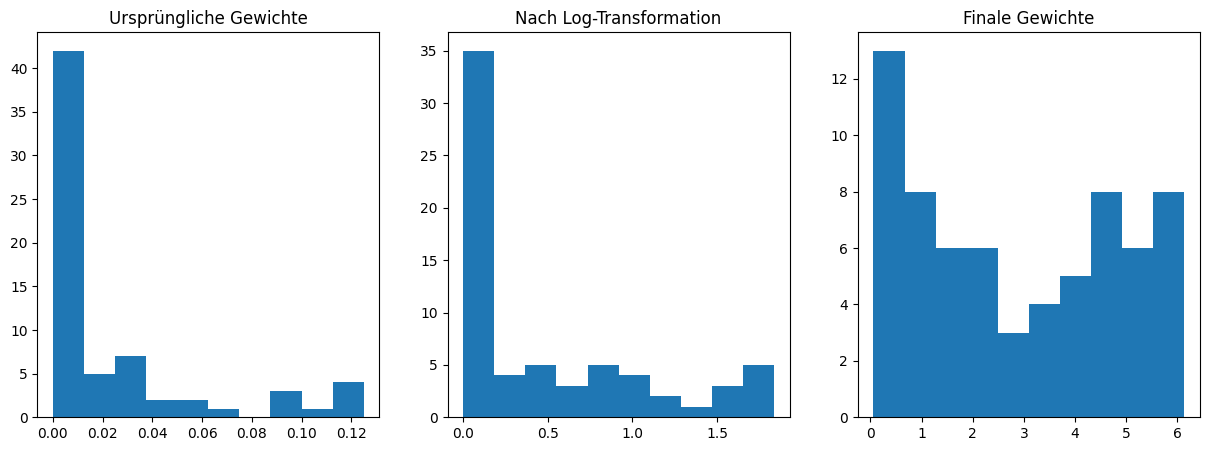

In [16]:
import matplotlib.pyplot as plt

# Ursprüngliche Gewichte
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.hist(class_weights1)
plt.title('Ursprüngliche Gewichte')

# Nach Log-Transformation
plt.subplot(1,3,2)
plt.hist(np.log1p(class_weights2))
plt.title('Nach Log-Transformation')

# Finale Gewichte
plt.subplot(1,3,3)
plt.hist(class_weights3)
plt.title('Finale Gewichte')
plt.show()


In [17]:
weight_tensor = weight_tensor3



Training Set Statistiken:
Anzahl der Werte: 12688838
Mittelwert: 14227033.07
Standardabweichung: 82036636.81
Median: 6.00
Min: 0.00
Max: 2144920424.00


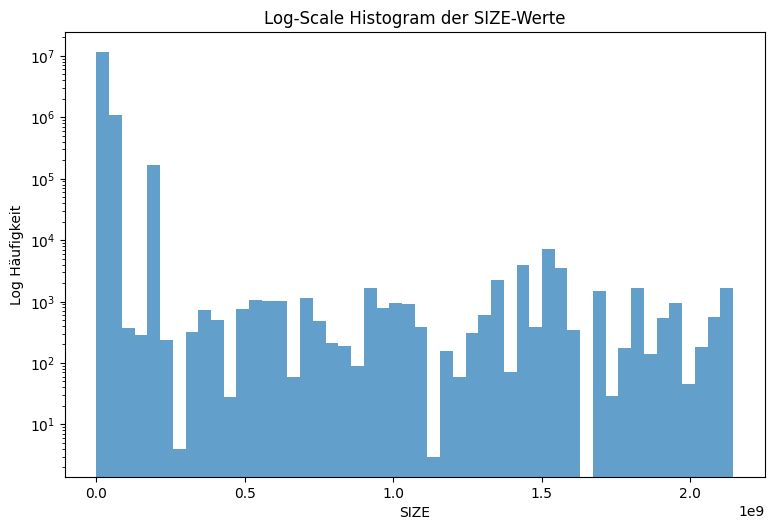


Wertebereiche:
SIZE zwischen -inf und 0: 0 (0.00%)
SIZE zwischen 0 und 1000: 8719443 (68.72%)
SIZE zwischen 1000 und 10000: 967404 (7.62%)
SIZE zwischen 10000 und 100000: 180096 (1.42%)
SIZE zwischen 100000 und inf: 2821895 (22.24%)

Test auf Normalverteilung p-value: 0.0
Die Verteilung ist wahrscheinlich nicht normal (p < 0.05)


In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

def analyze_size_distribution(X_train, X_val, X_test):
    """
    Analysiert die Verteilung der SIZE-Werte in den Datensätzen
    """
    # Sammle alle SIZE-Werte (Index 10)
    sizes_train = []
    sizes_val = []
    sizes_test = []
    
    for sequence in X_train:
        sizes_train.extend(sequence[:, 10])
    for sequence in X_val:
        sizes_val.extend(sequence[:, 10])
    for sequence in X_test:
        sizes_test.extend(sequence[:, 10])
    
    # Konvertiere zu numpy arrays
    sizes_train = np.array(sizes_train)
    sizes_val = np.array(sizes_val)
    sizes_test = np.array(sizes_test)
    
    # Berechne Statistiken
    print("\nTraining Set Statistiken:")
    print(f"Anzahl der Werte: {len(sizes_train)}")
    print(f"Mittelwert: {np.mean(sizes_train):.2f}")
    print(f"Standardabweichung: {np.std(sizes_train):.2f}")
    print(f"Median: {np.median(sizes_train):.2f}")
    print(f"Min: {np.min(sizes_train):.2f}")
    print(f"Max: {np.max(sizes_train):.2f}")
    
    # Erstelle Plots
    plt.figure(figsize=(15, 10))
    
    
    # Log-Scale Histogram
    plt.subplot(2, 2, 2)
    plt.hist(sizes_train, bins=50, alpha=0.7, log=True)
    plt.title('Log-Scale Histogram der SIZE-Werte')
    plt.xlabel('SIZE')
    plt.ylabel('Log Häufigkeit')
    
    
    plt.tight_layout()
    plt.show()
    
    # Zusätzliche Analysen
    print("\nWertebereiche:")
    ranges = [(float('-inf')  , 0), (0, 1000), (1000, 10000), (10000, 100000), (100000, float('inf'))]
    for start, end in ranges:
        count = np.sum((sizes_train >= start) & (sizes_train < end))
        percentage = (count / len(sizes_train)) * 100
        print(f"SIZE zwischen {start} und {end}: {count} ({percentage:.2f}%)")
    
    # Test auf Normalverteilung
    _, p_value = stats.normaltest(sizes_train)
    print(f"\nTest auf Normalverteilung p-value: {p_value}")
    if p_value < 0.05:
        print("Die Verteilung ist wahrscheinlich nicht normal (p < 0.05)")
    else:
        print("Die Verteilung könnte normal sein (p >= 0.05)")

# Verwendung:
analyze_size_distribution(X_train, X_val, X_test)


Train: 247249
Validation: 48541
Test: 52084
X_train[0] [[ 0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.         -0.17342292  0.
   2.97027802  0.          0.          0.          0.69150335  1.52973974
   0.          0.          3.3184731   0.          0.          0.87207317
   3.30695677  0.          0.          0.          3.47280598  0.
   2.3151474   2.58476567  0.57504863  0.          0.          0.
   0.          0.          0.          0.70897317  0.13242683  2.94519401
   0.          0.          0.          2.98629904  2.88327932  4.87528276
   0.          3.95268607  0.79194558  0.12444903  0.          2.72086287
   0.          0.          0.          3.40203428  0.          0.
   0.          0.          0.          1.09633613  0.          0.
   0.          0.          1.65924406  0.          0.          0.
   4.24345303  0.          0.          0.          1.63741601  0.34174347
   2.99532294  2.79648399  0.          

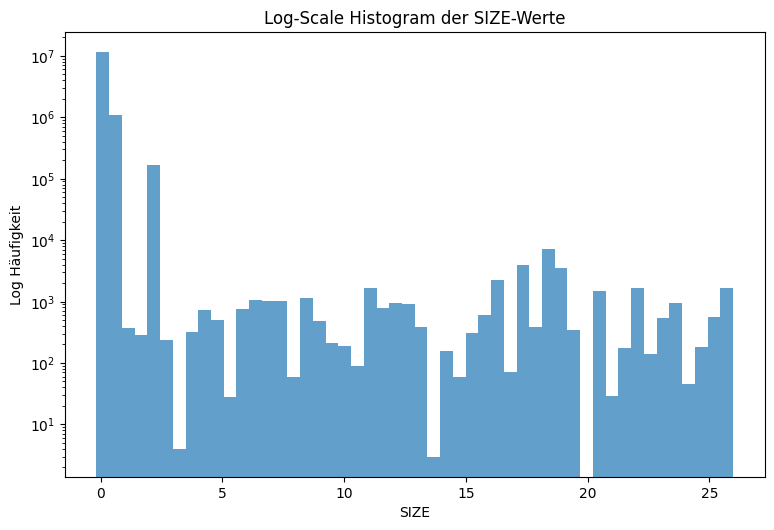


Wertebereiche:
SIZE zwischen -inf und 0: 10879450 (85.74%)
SIZE zwischen 0 und 1000: 1809388 (14.26%)
SIZE zwischen 1000 und 10000: 0 (0.00%)
SIZE zwischen 10000 und 100000: 0 (0.00%)
SIZE zwischen 100000 und inf: 0 (0.00%)

Test auf Normalverteilung p-value: 0.0
Die Verteilung ist wahrscheinlich nicht normal (p < 0.05)


In [19]:
from sklearn.preprocessing import StandardScaler

def normalize_size_feature(X_train, X_val, X_test):
    """
    Normalisiert nur das SIZE Feature
    SIZE befindet sich an Index 10 in den Sequenzen
    """
    # Initialisiere Scaler
    size_scaler = StandardScaler()
    
    # Sammle alle SIZE Werte aus dem Training Set
    sizes_train = []
    for sequence in X_train:
        sizes_train.extend(sequence[:, 10].reshape(-1, 1))
    
    # Fit Scaler nur auf Trainingsdaten
    size_scaler.fit(sizes_train)
    
    # Transformationsfunktion für eine einzelne Sequenz
    def transform_sequence(sequence):
        seq_transformed = sequence.copy()
        seq_transformed[:, 10] = size_scaler.transform(sequence[:, 10].reshape(-1, 1)).flatten()
        return seq_transformed
    
    # Transformiere alle Datensätze
    X_train_norm = [transform_sequence(seq) for seq in X_train]
    X_val_norm = [transform_sequence(seq) for seq in X_val]
    X_test_norm = [transform_sequence(seq) for seq in X_test]
    
    return X_train_norm, X_val_norm, X_test_norm

# Verwendung:
X_train, X_val, X_test = normalize_size_feature(X_train, X_val, X_test)

# print lengths
print(f'Train: {len(y_train)}')
print(f'Validation: {len(y_val)}')
print(f'Test: {len(y_test)}')

#print shape                                         
print(f"X_train[0] {X_train[0]}")                    # Beispielsequnez
print(f"X_train[0][0].shape: {len(X_train[0][0])}")  # Länge eines einzelnen Vektors
print(f"X_train[0].shape: {len(X_train[0])}")        # Länge der Sequenz

lengths = set(len(seq[0]) for seq in X_train)
print(f"Unterschiedliche Vektorlängen im Training-Set: {lengths}")

analyze_size_distribution(X_train, X_val, X_test)


In [20]:
feature_vector_cardinality = X_train[0].shape[1]
print(f'Feature vector cardinality: {feature_vector_cardinality}')

input_dim = X_train[0][0].shape[0]  # Neue Dimension nach One-Hot-Encoding
print(input_dim)


Feature vector cardinality: 107
107


In [21]:
class FeatureEmbedding(nn.Module):
    def __init__(
        self,
        d_model: int,
        event_types_cardinality: int = 29,
        users_cardinality: int = 16,
        addr_cardinality: int = 4,
        port_cardinality: int = 9,
        dropout: float = 0.1
    ):
        super().__init__()
        
        # Embedding Dimensionen
        self.event_dim = 32
        self.user_dim = 16
        self.addr_dim = 8
        self.port_dim = 8
        
        # Embeddings für kategorische Features
        self.event_embedding = nn.Embedding(event_types_cardinality, self.event_dim)
        self.user_embedding = nn.Embedding(users_cardinality, self.user_dim)
        self.addr_embedding = nn.Embedding(addr_cardinality, self.addr_dim)
        self.port_embedding = nn.Embedding(port_cardinality, self.port_dim)
        
        # Lineare Projektionen auf d_model
        self.event_proj = nn.Linear(self.event_dim, d_model)
        self.user_proj = nn.Linear(self.user_dim, d_model)
        self.addr_proj = nn.Linear(self.addr_dim, d_model)
        self.port_proj = nn.Linear(self.port_dim, d_model)
        self.size_proj = nn.Linear(1, d_model)
        self.path_proj = nn.Linear(96, d_model)  # 96 = 2 * 48 (PATH_EMBEDDINGS)
        
        self.dropout = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(d_model)
    
    def embed_network_pair(self, local_ip, local_port, remote_ip, remote_port):
        """Verarbeitet ein Paar von Netzwerk-Features (lokal und remote)"""
        local_ip_emb = self.addr_proj(self.addr_embedding(local_ip))
        local_port_emb = self.port_proj(self.port_embedding(local_port))
        remote_ip_emb = self.addr_proj(self.addr_embedding(remote_ip))
        remote_port_emb = self.port_proj(self.port_embedding(remote_port))
        
        return local_ip_emb + local_port_emb + remote_ip_emb + remote_port_emb
        
    def forward(self, x):
        """
        Input: x shape [batch_size, seq_len, 107]
        Output: shape [batch_size, seq_len, d_model]
        """
        # Basis-Features
        event = x[:, :, 0].long()
        user = x[:, :, 1].long()
        size = x[:, :, 10:11]
        paths = x[:, :, 11:]
        
        # Netzwerk-Features aufteilen
        local_ip1 = x[:, :, 2].long()
        local_port1 = x[:, :, 3].long()
        remote_ip1 = x[:, :, 4].long()
        remote_port1 = x[:, :, 5].long()
        
        local_ip2 = x[:, :, 6].long()
        local_port2 = x[:, :, 7].long()
        remote_ip2 = x[:, :, 8].long()
        remote_port2 = x[:, :, 9].long()
        
        # Basis-Embeddings
        event_emb = self.event_proj(self.event_embedding(event))
        user_emb = self.user_proj(self.user_embedding(user))
        size_emb = self.size_proj(size)
        path_emb = self.path_proj(paths)
        
        # Netzwerk-Embeddings
        net_pair1_emb = self.embed_network_pair(local_ip1, local_port1, remote_ip1, remote_port1)
        net_pair2_emb = self.embed_network_pair(local_ip2, local_port2, remote_ip2, remote_port2)
        netinfo_emb = net_pair1_emb + net_pair2_emb
        
        # Kombiniere alle Features
        combined = (
            event_emb + 
            user_emb + 
            netinfo_emb + 
            size_emb + 
            path_emb
        )
        
        # Normalisierung und Dropout
        output = self.layer_norm(combined)
        output = self.dropout(output)
        
        return output


In [22]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout, max_len):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        
        # Positional Encoding Matrix berechnen
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        
        pe = torch.zeros(1, max_len, d_model)
        pe[0, :, 0::2] = torch.sin(position * div_term)
        pe[0, :, 1::2] = torch.cos(position * div_term)
        
        # Registrieren als Buffer (wird mit dem Modell gespeichert)
        self.register_buffer('pe', pe)
        
    def forward(self, x):
        """
        Args:
            x: Tensor mit Shape [batch_size, seq_len, d_model]
        """
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)


In [23]:
class TransformerEncoder(nn.Module):
    def __init__(
        self,
        input_dim: int,
        num_classes: int,
        model_dim: int,
        num_encoder_layers: int,
        num_heads: int,
        max_len: int,
        dim_feed_forward: int,
        dropout_rate: float,
        activation: str,
        padding_idx: int,
        pos_encoding_scaling: float,
        pooling_type: str,
        norm_first: bool,
        embedding: bool,
        event_types_cardinality,
        users_cardinality,
        addr_cardinality,
        port_cardinality
        
    ):
        super(TransformerEncoder, self).__init__()
        
        self.pooling_type = pooling_type.lower()
        if self.pooling_type not in ["mean", "cls"]:
            raise ValueError("pooling_type muss 'mean' oder 'cls' sein")
        
        # CLS Token nur erstellen wenn nötig
        self.cls_token = nn.Parameter(torch.randn(1, 1, model_dim)) if self.pooling_type == "cls" else None
        
        self.embedding = embedding
        
        if self.embedding:
            self.feature_embedding = FeatureEmbedding(
                d_model=model_dim,
                event_types_cardinality=event_types_cardinality,
                users_cardinality=users_cardinality,
                addr_cardinality=addr_cardinality,
                port_cardinality=port_cardinality,
                dropout=dropout_rate
            )
        else:
            self.input_projection = nn.Linear(input_dim, model_dim)
            self.input_norm = nn.LayerNorm(model_dim)
            
        
        # Positionsencoding länge anpassen wenn CLS Token verwendet wird
        max_len_adjusted = max_len + 1 if self.pooling_type == "cls" else max_len
        self.pos_encoder = PositionalEncoding(model_dim, dropout_rate, max_len_adjusted)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=model_dim,
            nhead=num_heads,
            dim_feedforward=dim_feed_forward,
            dropout=dropout_rate,
            activation=activation,
            norm_first=norm_first,
            batch_first=True
        )
        
        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_encoder_layers,
            norm=nn.LayerNorm(model_dim)
        )
        
        self.dropout = nn.Dropout(dropout_rate)
        
        self.classifier = nn.Sequential(
            nn.LayerNorm(model_dim),
            nn.Linear(model_dim, model_dim),
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.LayerNorm(model_dim),
            nn.Linear(model_dim, num_classes)
        )
        
        self.init_weights()
        self.pos_encoding_scaling = pos_encoding_scaling
        
    def init_weights(self):
        def _init_weights(m):
            if isinstance(m, nn.Linear):
                torch.nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    torch.nn.init.zeros_(m.bias)
        
        self.apply(_init_weights)
        # CLS Token separat initialisieren falls vorhanden
        if self.cls_token is not None:
            torch.nn.init.normal_(self.cls_token, std=0.02)
    
    def mean_pooling(self, x: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
        mask = attention_mask.unsqueeze(-1).float()
        return torch.sum(x * mask, dim=1) / (torch.sum(mask, dim=1) + 1e-4)
    
    def cls_pooling(self, x: torch.Tensor) -> torch.Tensor:
        return x[:, 0]
        
    def forward(
        self,
        x: torch.Tensor,
        attention_mask: torch.Tensor
    ) -> torch.Tensor:
        batch_size = x.shape[0]
        
        
        #Use Embedding or One Hot Encoding
        if self.embedding:
            x = self.feature_embedding(x)
        else:
            x = self.input_projection(x)
            x = self.input_norm(x)
        
        
        if self.pooling_type == "cls":
            # CLS Token hinzufügen
            cls_tokens = self.cls_token.expand(batch_size, -1, -1)
            x = torch.cat((cls_tokens, x), dim=1)
            
            # Attention Mask für CLS Token erweitern
            cls_mask = torch.ones((batch_size, 1), device=attention_mask.device)
            attention_mask = torch.cat((cls_mask, attention_mask), dim=1)
        
        #Anwendung Poitional Encoding
        x = self.pos_encoder(x)
        
        padding_mask = ~attention_mask.bool()
        
        x = self.encoder(x, src_key_padding_mask=padding_mask)
        
        # Pooling basierend auf gewählter Strategie
        if self.pooling_type == "mean":
            x = self.mean_pooling(x, attention_mask)
        else:  # cls
            x = self.cls_pooling(x)
        
        logits = self.classifier(x)
        
        return logits


In [24]:
class SequenceDataset(Dataset):
    def __init__(self, X, y, fixed_length):
        self.X = X
        self.y = y
        self.fixed_length = fixed_length
        
    def __len__(self):
        return len(self.X)
        
    def __getitem__(self, idx):
        # Einzelne Sequenz holen
        x = self.X[idx]
        y = self.y[idx]
        
        # Attention Mask erstellen (1 für echte Daten, 0 für padding)
        attention_mask = torch.ones(self.fixed_length)
        
        # Padding/Truncating
        if len(x) < self.fixed_length:
            # Mask auf 0 setzen für Padding-Bereich
            attention_mask[len(x):] = 0
            
            # Padding für die Sequenz
            padding = np.zeros((self.fixed_length - len(x), x.shape[1]))
            x = np.concatenate([x, padding], axis=0)
        else:
            x = x[:self.fixed_length]
            
        x = torch.FloatTensor(x)
        y = torch.FloatTensor([y])
        return x,  y, attention_mask



 # Focal Cross Entropy Loss



 ## Was ist Focal Loss?

 Focal Loss ist eine Modifikation des Standard Cross Entropy Loss, die entwickelt wurde, um das Problem unbalancierter Datensätze besser zu handhaben. Der Hauptunterschied liegt in der zusätzlichen Gewichtung schwieriger Beispiele durch den Focal Term `(1-pt)^γ`.



 ## Formel



 $FL(p_t) = -(1-p_t)^\gamma \log(p_t)$



 Wobei:

 - `pt` ist die Modellvorhersagewahrscheinlichkeit für die wahre Klasse

 - `γ` (gamma) ist der Focusing Parameter (typischerweise γ = 2)



 ## Vorteile

 - Reduziert den Einfluss einfach zu klassifizierender Beispiele

 - Fokussiert das Training auf schwierige Fälle

 - Besonders effektiv bei stark unbalancierten Datensätzen



 ## Parameter

 - `gamma`: Steuert die Stärke der Gewichtung (höhere Werte = stärkerer Fokus auf schwierige Fälle)

 - Behält alle Standard-Parameter von CrossEntropyLoss (label_smoothing, weight, etc.)



 ## Code-Beispiel

 ```python

 criterion = FocalCrossEntropyLoss(

     gamma=2.0,               # Focal Loss Stärke

     label_smoothing=0.1,     # Optional: Label Smoothing

     weight=class_weights     # Optional: Klassengewichte

 )

 ```



 ## Wann verwenden?



 - bei unbalancierten Datensätzen

 - wenn das Modell Schwierigkeiten hat, bestimmte Klassen zu lernen





 ## Hauptparameter



 ### gamma (float, optional)

 - **Default:** 2.0

 - **Beschreibung:** Focal Loss Parameter, der die Gewichtung schwieriger Beispiele steuert

 - **Wertebereich:** ≥ 0

 - **Verwendung:** Höhere Werte verstärken den Fokus auf schwierige Beispiele



 ### weight (Tensor, optional)

 - **Default:** None

 - **Beschreibung:** Manuelle Gewichtung für jede Klasse

 - **Format:** 1D Tensor der Größe C (Anzahl der Klassen)

 - **Verwendung:** Nützlich bei unbalancierten Datensätzen



 ### label_smoothing (float, optional)

 - **Default:** 0.0

 - **Beschreibung:** Glättungsfaktor für die Ziel-Labels

 - **Wertebereich:** [0.0, 1.0]

 - **Verwendung:** Verhindert Überanpassung und verbessert Generalisierung





 ## Reduktions-Parameter



 ### reduction (str, optional)

 - **Default:** 'mean'

 - **Optionen:**

   - 'none': Keine Reduktion

   - 'mean': Gewichteter Mittelwert

   - 'sum': Summe aller Verluste

 - **Verwendung:** Bestimmt, wie der Loss über den Batch aggregiert wird



 ### ignore_index (int, optional)

 - **Default:** 0

 - **Beschreibung:** Target-Wert, der ignoriert wird

 - **Verwendung:** Nützlich für Padding oder spezielle Klassen





In [25]:
class FocalCrossEntropyLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None, reduction='mean', label_smoothing=0.0, epsilon=1e-7):
        super().__init__()
        self.gamma = gamma
        self.weight = weight
        self.reduction = reduction
        self.label_smoothing = label_smoothing
        self.epsilon = epsilon  # Neue Epsilon-Konstante für numerische Stabilität
        self.ce_loss = nn.CrossEntropyLoss(
            weight=weight,
            reduction='none',
            label_smoothing=label_smoothing
        )

    def forward(self, input, target):
        # Berechne standard cross entropy loss
        ce_loss = self.ce_loss(input, target)
        
        # Berechne korrekte Wahrscheinlichkeiten mit Softmax
        pt = torch.softmax(input, dim=1)  # Wandelt Logits in Wahrscheinlichkeiten um
        pt = pt.gather(1, target.unsqueeze(1)).squeeze()  # Extrahiert die Wahrscheinlichkeiten der wahren Klassen
        
        # Verhindere numerische Instabilität
        pt = torch.clamp(pt, min=self.epsilon, max=1.0)
        
        # Berechne Focal Term
        focal_term = (1 - pt) ** self.gamma
        
        # Kombiniere CE Loss und Focal Term
        focal_loss = focal_term * ce_loss

        # Reduction wie bei standard CrossEntropyLoss
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:  # 'none'
            return focal_loss


In [26]:
class_counts = y_train.sum(axis=0)
print("Class counts:", class_counts)


Class counts: [5.2000e+01 1.5780e+03 1.0290e+03 1.1070e+03 2.1000e+01 8.0000e+00
 5.8322e+04 1.2400e+02 1.3100e+03 2.2000e+01 1.4200e+02 2.9350e+03
 5.6860e+03 5.8200e+02 2.4100e+02 6.7000e+01 1.1000e+01 1.0000e+01
 7.5540e+03 4.2600e+02 3.5000e+01 5.6870e+03 4.6000e+01 1.0362e+04
 1.3600e+03 8.0000e+00 2.7000e+01 4.2430e+03 1.8000e+01 5.0000e+01
 4.0042e+04 8.0000e+00 1.5000e+01 2.7070e+03 8.7000e+01 3.1000e+01
 2.3620e+03 9.0000e+00 4.0150e+03 2.5000e+02 8.4000e+01 6.3600e+02
 3.0890e+03 1.3630e+03 2.8000e+01 2.6548e+04 4.2100e+02 1.7800e+02
 3.4000e+01 1.7000e+01 9.3000e+01 9.2470e+03 2.2814e+04 3.5130e+03
 8.0000e+00 1.9560e+03 1.2100e+02 6.0100e+02 2.9000e+01 8.9300e+03
 1.8750e+03 1.0000e+01 5.7500e+02 6.2000e+01 1.1516e+04 3.3000e+01
 8.7900e+02]


In [27]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
import seaborn as sns
from datetime import datetime
import wandb
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingLR




num_epochs = 200
early_stopping_patience = 7

#tensor needs to be on the GPU
weight_tensor = weight_tensor.to(device)




def train_epoch(epoch, model, criterion, optimizer,  train_loader, l1_lambda):
    model.train()
    total_loss = 0
    correct_predictions = 0
    total_predictions = 0
    all_predictions = []
    all_labels = []
    
    
    progress_bar = tqdm(train_loader, desc="Training")
    
    for sequences, labels, attention_masks in progress_bar:
        sequences = sequences.to(device)
        labels = labels.to(device)
        attention_masks = attention_masks.to(device)
        
        optimizer.zero_grad()
        outputs = model(sequences, attention_masks)
        
        labels = labels.squeeze(1)
        labels = torch.argmax(labels, dim=1)
        
        loss = criterion(outputs, labels)
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")
        
        

        
        # L1 Regularisierung hinzufügen
        l1_norm = sum(p.abs().sum() for p in model.parameters())
        current_loss = loss + l1_lambda * l1_norm
        current_loss.backward()
        total_loss += loss.item()

        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        predictions = torch.argmax(outputs, dim=1)
        correct_predictions += (predictions == labels).sum().item()
        total_predictions += labels.size(0)
        
        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
        progress_bar.set_postfix({
            'loss': f"{loss.item():.4f}",
            'acc': f"{correct_predictions/total_predictions:.4f}"
        })
    
    avg_loss = total_loss / len(train_loader)
    accuracy = correct_predictions / total_predictions
    
    report = classification_report(
        all_labels, 
        all_predictions, 
        target_names=class_names, 
        output_dict=True
    )
    

    # Extrahiere Makro- und Support-gewichtete Metriken
    macro_precision = report['macro avg']['precision']
    macro_recall = report['macro avg']['recall']
    macro_f1 = report['macro avg']['f1-score']

    weighted_precision = report['weighted avg']['precision']
    weighted_recall = report['weighted avg']['recall']
    weighted_f1 = report['weighted avg']['f1-score']

    return {
        'train/loss': avg_loss,
        'train/accuracy': accuracy,
        'train/precision_weighted': weighted_precision,
        'train/recall_weighted': weighted_recall,
        'train/f1_weighted': weighted_f1,
        'train/precision_macro': macro_precision,
        'train/recall_macro': macro_recall,
        'train/f1_macro': macro_f1
    }

@torch.no_grad()
def validate(epoch, model, criterion, val_loader):
    model.eval()
    total_loss = 0
    correct_predictions = 0
    total_predictions = 0
    all_predictions = []
    all_labels = []
    metrics_table_data = []
    
    progress_bar = tqdm(val_loader, desc="Validating")
    
    for sequences, targets, attention_masks in progress_bar:
        sequences = sequences.to(device)
        targets = targets.to(device)
        attention_masks = attention_masks.to(device)
        
        outputs = model(sequences, attention_masks)
        targets = targets.squeeze(1)
        targets = torch.argmax(targets, dim=1)
        
        loss = criterion(outputs, targets)
        total_loss += loss.item()
        predictions = torch.argmax(outputs, dim=1)
        correct_predictions += (predictions == targets).sum().item()
        total_predictions += targets.size(0)
        
        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(targets.cpu().numpy())
    
    avg_loss = total_loss / len(val_loader)
    accuracy = correct_predictions / total_predictions
    

    print(f"Unique labels in dataset: {set(all_labels)}")
    from collections import Counter
    class_distribution = Counter(all_labels)
    print(f"Class distribution: {class_distribution}")


    confusion_mat = confusion_matrix(all_labels, all_predictions, normalize='true')


    # Berechne den Classification Report
    report = classification_report(
        all_labels, 
        all_predictions, 
        target_names=class_names, 
        output_dict=True
    )
    
    # Füge Daten für jede Klasse hinzu
    for class_name in class_names:
        metrics_table_data.append([
            class_name,
            report[class_name]['precision'],
            report[class_name]['recall'],
            report[class_name]['f1-score'],
            report[class_name]['support']
        ])
    
    # Füge auch die durchschnittlichen Metriken hinzu
    metrics_table_data.append([
        'macro avg',
        report['macro avg']['precision'],
        report['macro avg']['recall'],
        report['macro avg']['f1-score'],
        report['macro avg']['support']
    ])
    
    metrics_table_data.append([
        'weighted avg',
        report['weighted avg']['precision'],
        report['weighted avg']['recall'],
        report['weighted avg']['f1-score'],
        report['weighted avg']['support']
    ])

    # Erstelle W&B Tabelle
    metrics_table = wandb.Table(
        data=metrics_table_data,
        columns=["Class", "Precision", "Recall", "F1-Score", "Support"]
    )

    # Extrahiere Makro- und Support-gewichtete Metriken
    macro_precision = report['macro avg']['precision']
    macro_recall = report['macro avg']['recall']
    macro_f1 = report['macro avg']['f1-score']

    weighted_precision = report['weighted avg']['precision']
    weighted_recall = report['weighted avg']['recall']
    weighted_f1 = report['weighted avg']['f1-score']

    return {
        'val/loss': avg_loss, 
        'val/accuracy': accuracy,
        'val/precision_weighted': weighted_precision,
        'val/recall_weighted': weighted_recall,
        'val/f1_score_weighted': weighted_f1,
        'val/precision_macro': macro_precision,
        'val/recall_macro': macro_recall,
        'val/f1_score_macro': macro_f1,
        'val/confusion_matrix': confusion_mat,
        'val/metrics_table': metrics_table
    }
    

    


def train():
    best_f1_score = float('-inf')
    patience_counter = 0
    
    
    
    run = wandb.init()
    
    # Create save directory using wandb run name and id
    save_dir = f"models/{run.name}_{run.id}"
    os.makedirs(save_dir, exist_ok=True)
    
    
    # Model Initilization
    model = TransformerEncoder(
        input_dim=feature_vector_cardinality,
        num_classes=labels_cardinality,
        model_dim=wandb.config.model_dim,
        num_encoder_layers=wandb.config.num_encoder_layers,
        num_heads=wandb.config.num_heads,
        max_len=100,
        dim_feed_forward= 4 * wandb.config.model_dim,
        dropout_rate=wandb.config.dropout_rate,
        activation=wandb.config.activation,
        padding_idx=0,
        pos_encoding_scaling=wandb.config.pos_encoding_scaling,
        pooling_type=wandb.config.pooling_type,
        norm_first=wandb.config.norm_first,
        embedding=wandb.config.embedding,
        event_types_cardinality=event_types_cardinality,
        users_cardinality=users_cardinality,
        addr_cardinality=addr_cardinality,
        port_cardinality=port_cardinality
    )    
    
    # Optimizer and Loss-Function Intilization
    
    if(wandb.config.optimizer == 'adam'):
        optimizer = torch.optim.Adam(model.parameters(), lr=wandb.config.learning_rate, weight_decay=wandb.config.weight_decay)
    else: 
        optimizer = torch.optim.AdamW(model.parameters(), lr=wandb.config.learning_rate, weight_decay=wandb.config.weight_decay)       
    
    
    
    
    if wandb.config.loss_type == 'focal':
        criterion = FocalCrossEntropyLoss(
            gamma=wandb.config.focal_gamma,
            label_smoothing=wandb.config.label_smoothing,
            reduction=wandb.config.loss_reduction,
            weight=weight_tensor
        )
    else:
        criterion = nn.CrossEntropyLoss(
            weight=weight_tensor,
            label_smoothing=wandb.config.label_smoothing
        )
    
    
    model = model.to(device)

    
    
    # Dataset und Loader Initilization
    train_dataset = SequenceDataset(X_train, y_train, 100)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=wandb.config.batch_size, shuffle=True)
    val_dataset = SequenceDataset(X_val,y_val, 100)
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=wandb.config.batch_size, shuffle=True)

    
    
    if(wandb.config.lr_scheduler == 'CosineAnnealingLR'):
        scheduler = CosineAnnealingLR(optimizer,T_max=num_epochs)
    elif(wandb.config.lr_scheduler == 'ReduceLROnPlateau'):
        scheduler = ReduceLROnPlateau(optimizer, 'max', patience=5, factor=0.6)
    else:
        scheduler = None
        
        
    l1_lambda = wandb.config.l1_lambda
    
        

    
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        
        
        
        #Log Learning rate
        current_lr = optimizer.param_groups[0]['lr']
        wandb.log({"learning_rate": current_lr}, step=epoch)
        
        # Training
        train_metrics = train_epoch(epoch, model, criterion, optimizer,  train_loader, l1_lambda)
        print(train_metrics)
        wandb.log({
            "train/loss": train_metrics["train/loss"],
            "train/accuracy": train_metrics["train/accuracy"],
            "train/precision_weighted": train_metrics["train/precision_weighted"],
            "train/recall_weighted": train_metrics["train/recall_weighted"],
            "train/f1_weighted": train_metrics["train/f1_weighted"],
            "train/precision_macro": train_metrics["train/precision_macro"],
            "train/recall_macro": train_metrics["train/recall_macro"],
            "train/f1_macro": train_metrics["train/f1_macro"]
        }, step=epoch)
        
        
        # Validation
        val_metrics = validate(epoch, model, criterion, val_loader)
        print(val_metrics)
        wandb.log({
            'val/loss': val_metrics['val/loss'], 
            'val/accuracy': val_metrics['val/accuracy'],
            'val/precision_weighted': val_metrics['val/precision_weighted'],
            'val/recall_weighted': val_metrics['val/recall_weighted'],
            'val/f1_score_weighted': val_metrics['val/f1_score_weighted'],
            'val/precision_macro': val_metrics['val/precision_macro'],
            'val/recall_macro': val_metrics['val/recall_macro'],
            'val/f1_score_macro': val_metrics['val/f1_score_macro'],
            'class_metrics': val_metrics['val/metrics_table']
        }, step=epoch)
        
         # Create save directory using wandb run name and id
        save_dir_confusion_matrix = f"outputs/{run.name}_{run.id}"
        os.makedirs(save_dir_confusion_matrix, exist_ok=True)
        save_path_confusion_matrix = os.path.join(save_dir_confusion_matrix, f'model_epoch_{epoch}_loss_{best_f1_score:.4f}.png')

        
        plt.figure(figsize=(20,20))
        sns.heatmap(
            val_metrics['val/confusion_matrix'], 
            annot=False, 
            fmt='d', 
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names
        )
        plt.title(f'Confusion Matrix - Epoch {epoch}')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        
        # Rotiere die Labels für bessere Lesbarkeit bei vielen Klassen
        plt.xticks(rotation=90)
        plt.yticks(rotation=0)
        
        plt.tight_layout()
        plt.savefig(save_path_confusion_matrix, bbox_inches='tight', dpi=300)  # Erhöhte DPI für bessere Lesbarkeit
        plt.close()
        
        wandb.log({"confusion_matrix": wandb.Image(save_path_confusion_matrix)}, step=epoch)


        #scheduler step
        if(wandb.config.lr_scheduler == 'ReduceLROnPlateau'):
            scheduler.step(val_metrics['val/f1_score_macro'])   
        elif(wandb.config.lr_scheduler == 'CosineAnnealingLR'):
            scheduler.step()
        
    
        
        if val_metrics['val/f1_score_macro'] > best_f1_score:
            best_f1_score = val_metrics['val/f1_score_macro']
            patience_counter = 0
            
            # Create save path with epoch and loss
            save_path = os.path.join(save_dir, f'model_epoch_{epoch}_loss_{best_f1_score:.4f}.pt')
            
            # Save model state dict
            torch.save(model.state_dict(), save_path)
            
            # Log the saved model path to wandb
            wandb.log({"best_model_path": save_path}, step=epoch)
        else:
            patience_counter += 1
            if patience_counter >= early_stopping_patience:
                print(f"\nEarly stopping triggered after epoch {epoch+1}")
                break
        



In [ ]:

sweep_configuration = {
    'method': 'bayes',  
    'metric': {
        'goal': 'maximize', 
        'name': 'val/f1_score_macro'   # metric to optimize
    },
    'parameters': {
        'learning_rate': {
            'values': [0.001, 0.0001, 0.00001, 0.000001]
        },
        'dropout_rate': {
            'values': [0.1, 0.2, 0.3, 0.4]
        },
    
        'batch_size': {
            'values': [64, 128, 256]
        },
        'optimizer': {
            'values': ['adamw', 'adam']
        },
        'model_dim': {
            'values': [128, 256, 512]
        },
        'num_encoder_layers': {
            'values': [1, 2, 4, 5, 6]
        },
        'num_heads': {
            'values': [2, 4, 8, 16]
        },
        'pos_encoding_scaling': {
            'values': [1.0] 
        }, 
        'activation': {
            'values': ['relu', 'gelu']
        },
        'label_smoothing': {
            'values': [0.0, 0.01, 0.05 , 0.1, 0.2]
        },
        'pooling_type' : {
            'values': ['mean', 'cls']
        },
        'norm_first': {
            'values': [True, False]
        },
        'l1_lambda' : {
            'values': [1e-4, 1e-5, 0.0]
        },
        'weight_decay': {
            'values': [0.1, 0.01, 0.0]
        },
        'lr_scheduler': {
            'values': ['CosineAnnealingLR', 'ReduceLROnPlateau']
        },
        'embedding': {
            'values': [True]
        },
        'loss_type': {
            'values': ['focal']
        },
        'focal_gamma': {
            'values': [0.0, 1.0, 2.0, 3.0]
        },
        'loss_reduction': {
            'values': ['mean']
        }
    }
}

sweep_id = wandb.sweep(sweep=sweep_configuration, project="my-thirty-two-sweep")
wandb.agent(sweep_id, function=train, count=100)




wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


Create sweep with ID: xb1lluy2
Sweep URL: https://wandb.ai/johannes-st1999-hochschule-hannover/my-thirty-two-sweep/sweeps/xb1lluy2


wandb: Agent Starting Run: a7fegf51 with config:
wandb: 	activation: relu
wandb: 	batch_size: 128
wandb: 	dropout_rate: 0.1
wandb: 	embedding: True
wandb: 	focal_gamma: 0
wandb: 	l1_lambda: 1e-05
wandb: 	label_smoothing: 0.2
wandb: 	learning_rate: 0.0001
wandb: 	loss_reduction: mean
wandb: 	loss_type: focal
wandb: 	lr_scheduler: ReduceLROnPlateau
wandb: 	model_dim: 512
wandb: 	norm_first: False
wandb: 	num_encoder_layers: 5
wandb: 	num_heads: 16
wandb: 	optimizer: adamw
wandb: 	pooling_type: cls
wandb: 	pos_encoding_scaling: 1
wandb: 	weight_decay: 0.1
wandb: Currently logged in as: johannes-st1999 (johannes-st1999-hochschule-hannover). Use `wandb login --relogin` to force relogin



Epoch 1/200


Training:   0%|          | 0/1932 [00:00<?, ?it/s]/tmp/ipykernel_199076/799857815.py:30: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:278.)
  y = torch.FloatTensor([y])


...

Epoch 4, Loss: 0.9297


Training:  11%|█         | 217/1932 [00:45<06:06,  4.68it/s, loss=0.9379, acc=0.9808]

Epoch 4, Loss: 0.9379


Training:  11%|█▏        | 218/1932 [00:46<06:05,  4.69it/s, loss=0.9662, acc=0.9806]

Epoch 4, Loss: 0.9662
